In [1]:
#BIT 3444 - Project 02 - Nick Rini
#Military, Health, and Education Spending Analysis

In [2]:
#1. What date did you find your raw data?
#June 24
#2. What date did you start writing your code?
#June 24
#3. What date did you finish writing your code?
#June 29
#4. How many times did you review and modify your overall code?
#~35 times
#5. How many times did you review/redo your final presentation before submission?
#7 times

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Loads SIPRI military spending sheet
sipri_file_path = "SIPRI-Milex-data-1948-2023.xlsx"
sipri_file = pd.ExcelFile(sipri_file_path)

#Loads World Bank population, GDP, education, and healthcare spending sheets

pop_file_path = "API_SP.POP.TOTL_DS2_en_excel_v2_454480.xls"
pop_file = pd.ExcelFile(pop_file_path)

gdp_file_path = "API_NY.GDP.MKTP.CD_DS2_en_excel_v2_455111.xls"
gdp_file = pd.ExcelFile(gdp_file_path)

education_file_path = "Education_API_SE.XPD.TOTL.GD.ZS_DS2_en_excel_v2_560.xls"
education_file = pd.ExcelFile(education_file_path)

health_file_path = "Health_API_SH.XPD.CHEX.GD.ZS_DS2_en_excel_v2_15.xls"
health_file = pd.ExcelFile(health_file_path)

#World Bank population and World Bank gdp are external sources

In [5]:
#load the relevant sheet
df = pd.read_excel(sipri_file, 'Constant (2022) US$', skiprows=5)

#selects most recent years in given data (2022 and 2023 did not contain enough data between all of the datasets)
df = df[['Country', 2016, 2017, 2018, 2019, 2020, 2021]]
df = df.dropna()
df.head()

,Country,2016,2017,2018,2019,2020,2021
3,Algeria,10596.564106,10035.46938,9624.504002,10383.207823,10141.073361,9455.120355
4,Libya,...,...,...,...,...,...
5,Morocco,3599.711151,3705.59815,3731.482387,3809.704239,4883.245061,5026.030416
6,Tunisia,1004.52727,932.551601,936.298112,1151.413236,1205.706839,1210.355285
8,Angola,3331.954433,2882.802335,2376.791945,2171.788155,1901.093962,1619.929593


In [6]:
years = [year for year in range(2016, 2021+1)]

In [7]:
df[years] = df[years].apply(pd.to_numeric, errors='coerce')

# finds top 10 countries based on 2021 military spending
top_10_df = df.sort_values(by=2021, ascending=False).head(10)
top_10_df_indexed_by_country = top_10_df.set_index('Country')

In [8]:
 #transposes table axis
top_10_df_indexed_by_country_transposed = top_10_df_indexed_by_country.transpose()
top_10_df_indexed_by_country_transposed

Country,United States of America,China,Russia,India,Saudi Arabia,United Kingdom,Germany,France,"Korea, South",Japan
2016,780214.760274,220839.645542,92992.475502,64584.081714,69196.884815,58113.411315,43862.889529,50370.305371,37287.926085,40157.381998
2017,772175.855479,234421.626883,75353.784318,69133.650135,77154.423203,58219.584138,45120.983570,51033.026021,37973.843708,39891.730173
2018,795416.282151,248153.160601,72514.626378,71568.220179,79809.011040,58657.772557,46366.154236,49774.044672,39899.709610,41899.828092
2019,840614.812557,260242.521275,75764.914722,76620.727414,71410.026284,61094.449690,50860.823441,50596.382641,43113.963781,43091.611716
2020,880185.235566,272509.054677,77544.910059,77085.469741,68182.160900,62064.891239,54191.854601,52053.616019,45382.456885,42722.206666
2021,870751.188999,279605.778186,79081.150175,76596.864198,64758.149307,63008.189524,53715.839992,53011.698425,47359.240475,43660.127990


In [9]:
 #creates function that saves dataframes as png files
def save_df_png(dataframe, title, file_name):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)
    set_table = ax.table(cellText=dataframe.values,colLabels=dataframe.columns,loc='center')
    set_table.auto_set_font_size(False)
    set_table.set_fontsize(7)
    set_table.scale(1.2, 1.2)
    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    
    plt.show()

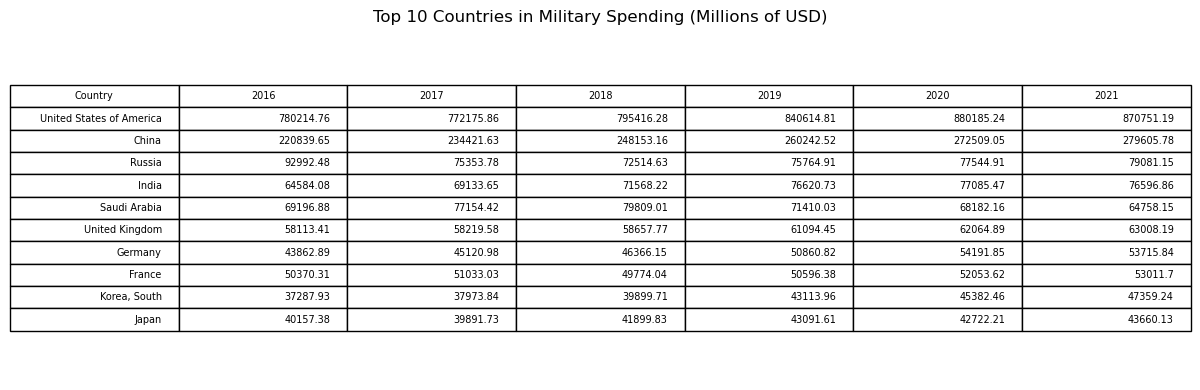

In [10]:
#Saves top 10 countries dataframe as png 
save_df_png(top_10_df.round(2), "Top 10 Countries in Military Spending (Millions of USD)", "top_military_table.png")

In [11]:
#creates line graph showing top military spending over time
def top_military_line_graph():

    country_list = top_10_df['Country'].tolist()

    plt.figure(figsize=(12,8))
    plt.plot(top_10_df_indexed_by_country_transposed, label=country_list)
    plt.title('Top 10 Countries in Military Spending')
    plt.xlabel('Year')
    plt.ylabel('Military Spending in USD (millions)')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1.01), loc='upper left')
    plt.savefig('top_military_line_graph.png')
    
    plt.show()

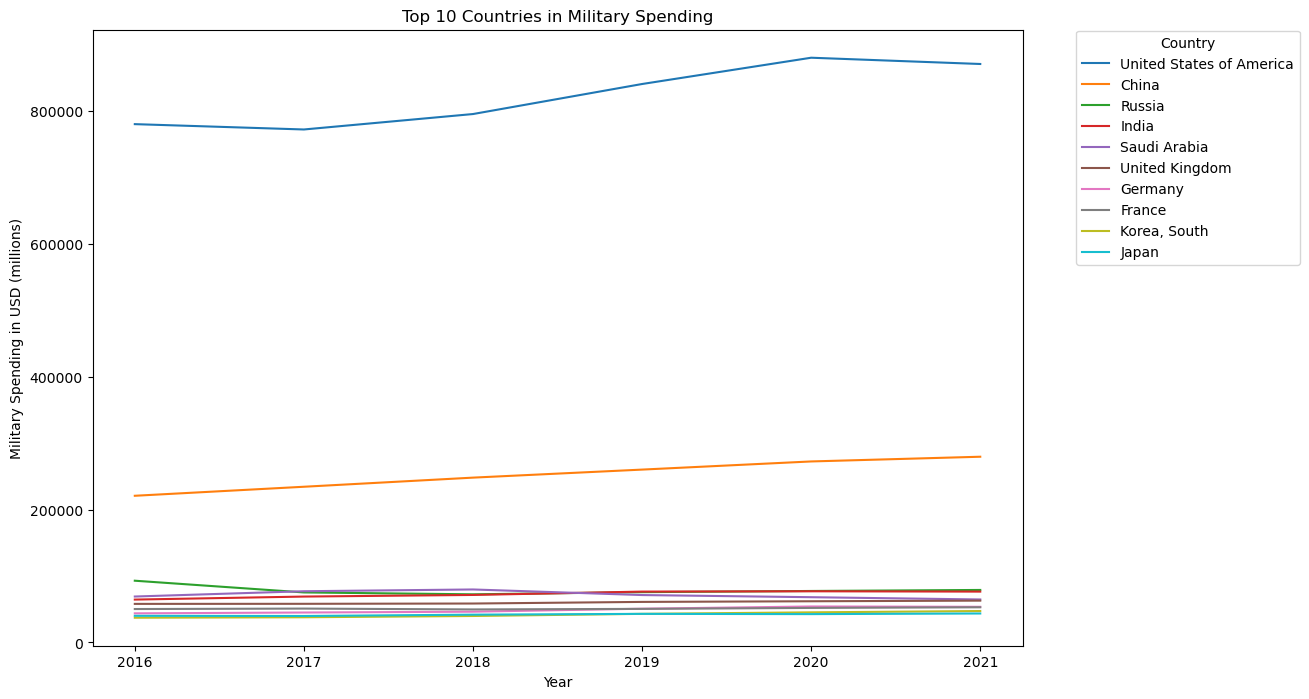

In [12]:
top_military_line_graph()

In [13]:
#Using Sipri sheet to show military spending compared to gdp
gdp_percent_df = pd.read_excel(sipri_file, 'Share of GDP', skiprows=5)

#keeps only the country column and same years used earlier
gdp_percent_df = gdp_percent_df[['Country'] + years]
gdp_percent_df[years] = gdp_percent_df[years].apply(pd.to_numeric, errors='coerce')

gdp_percent_df[years] = gdp_percent_df[years] * 100

# remove rows with missing values
gdp_percent_df = gdp_percent_df.dropna()

In [14]:
 #create list of same top 10 countries from military spending section
top_country_list = top_10_df['Country'].tolist()
top_gdp_percent_df = pd.DataFrame()

#adds each top 10 country into new data frame
for country in top_country_list:
    country_row = gdp_percent_df.loc[gdp_percent_df['Country'] == country]
    top_gdp_percent_df = pd.concat([top_gdp_percent_df, country_row])

In [15]:
top_gdp_portion = top_gdp_percent_df.set_index('Country')
top_gdp_portion

,2016,2017,2018,2019,2020,2021
Country,,,,,,
United States of America,3.402602,3.297724,3.304001,3.412158,3.650514,3.417094
China,1.768887,1.711243,1.673578,1.682911,1.756699,1.605260
Russia,5.425148,4.248996,3.719822,3.860338,4.171479,3.611741
India,2.543152,2.531511,2.424285,2.545998,2.807194,2.480389
Saudi Arabia,9.560482,9.846227,8.813335,7.794588,8.792174,7.229220
United Kingdom,1.984491,1.950029,1.944556,1.985254,2.162216,2.073222
Germany,1.151230,1.153404,1.170549,1.261841,1.374272,1.321027
France,1.917282,1.908642,1.843009,1.836461,1.996478,1.914406
"Korea, South",2.459578,2.421489,2.496844,2.671299,2.803322,2.797473


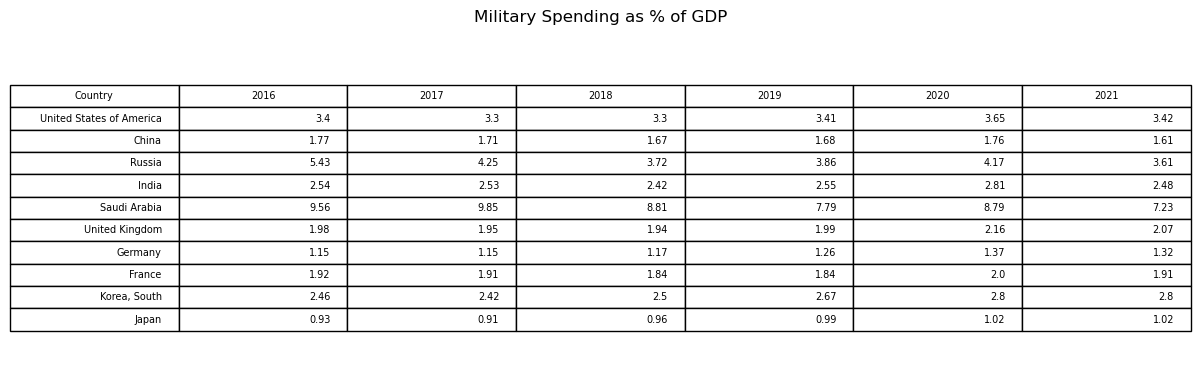

In [16]:
 #Save military spending as percent of gdp table as a png
save_df_png(top_gdp_percent_df.round(2),"Military Spending as % of GDP","military_spend_percent_GDP_table.png")

In [17]:
#makes line graph for military spending in proportion to GDP
def graph_military_pct_gdp():

    country_list = top_10_df['Country'].tolist()
    top_gdp_indexed_transposed = top_gdp_portion.transpose()
    
    plt.figure(figsize=(12,8))
    plt.plot(top_gdp_indexed_transposed, label=country_list)
    plt.title('Military Spending in Proportion to GDP')
    plt.xlabel('Year')
    plt.ylabel('Percentage')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1.01), loc='upper left')
    plt.tight_layout()

    plt.savefig('military_spend_pct_GDP_graph.png')
    plt.show()

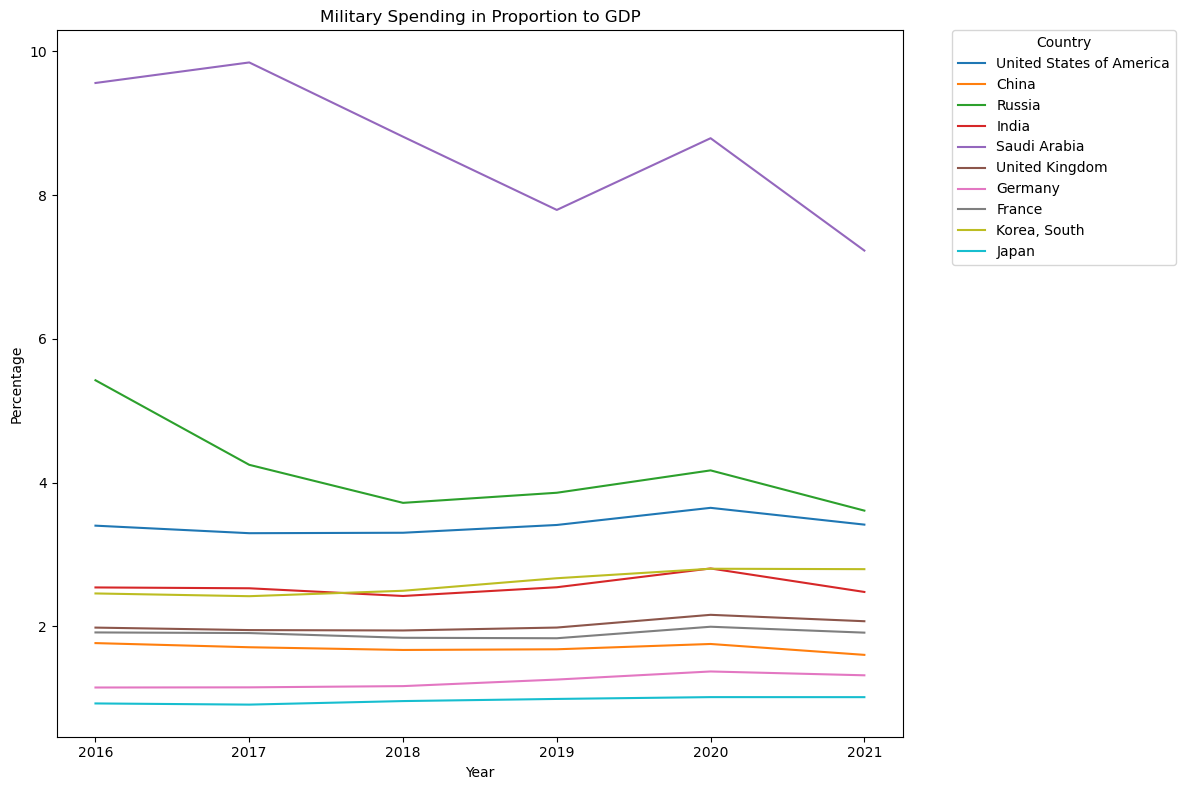

In [18]:
graph_military_pct_gdp()

In [19]:
#read data from world bank education spending
education_percent_df = pd.read_excel(education_file, 'Data', skiprows=3)

#keep country names and same years used earlier
world_bank_years = ['2016', '2017', '2018', '2019', '2020', '2021']
education_percent_df = education_percent_df[['Country Name'] + world_bank_years].copy()
education_percent_df = education_percent_df.rename(columns={'Country Name': 'Country'})
education_percent_df[world_bank_years] = education_percent_df[world_bank_years].apply(pd.to_numeric, errors='coerce')

In [20]:
#rename countries so they match SIPRI names
country_name_changes = {'United States': 'United States of America','Russian Federation': 'Russia','Korea, Rep.': 'Korea, South'}
education_percent_df['Country'] = education_percent_df['Country'].replace(country_name_changes)

 #convert world bank year column names from strings to numbers
year_name_changes = {'2016': 2016,'2017': 2017,'2018': 2018,'2019': 2019,'2020': 2020,'2021': 2021}

education_percent_df = education_percent_df.rename(columns=year_name_changes)
education_percent_df.head()

,Country,2016,2017,2018,2019,2020,2021
0,Aruba,5.49106,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,4.88207,4.820445,4.73975,4.511475,4.35244,4.67441
2,Afghanistan,4.54397,4.343190,NaN,NaN,NaN,NaN
3,Africa Western and Central,2.78355,3.535590,3.07200,3.100000,3.40400,3.28288
4,Angola,2.75500,2.467000,2.04500,2.073000,2.74500,2.29700


In [21]:
#creates list of same top countries from military spending
country_list = top_10_df['Country'].tolist()

#creates dataframe for top 10 education spending data
top_education_percent_df = pd.DataFrame()

#filters education spending data to only include same countries
for country in country_list:
    country_row = education_percent_df.loc[education_percent_df['Country'] == country]
    top_education_percent_df = pd.concat([top_education_percent_df, country_row])

top_education_percent_df


,Country,2016,2017,2018,2019,2020,2021
251,United States of America,4.80666,5.12288,4.928890,4.987280,5.435440,5.590000
40,China,3.76100,3.62400,3.542495,3.541055,3.572956,3.297843
202,Russia,3.76044,4.68991,4.678200,3.509326,3.701468,NaN
109,India,4.25700,4.30600,4.377000,3.897000,4.293000,4.635000
205,Saudi Arabia,NaN,NaN,NaN,NaN,NaN,NaN
81,United Kingdom,5.41511,5.43125,5.198070,5.248710,5.497700,5.400000
55,Germany,4.83923,4.87183,4.979330,5.116770,5.587590,4.510000
77,France,5.41000,5.45160,5.407170,5.354430,5.677840,5.240000
126,"Korea, South",4.33310,4.32824,4.458080,4.684660,4.801720,5.400000
119,Japan,3.14643,3.13058,3.077820,3.155340,3.306290,3.460000


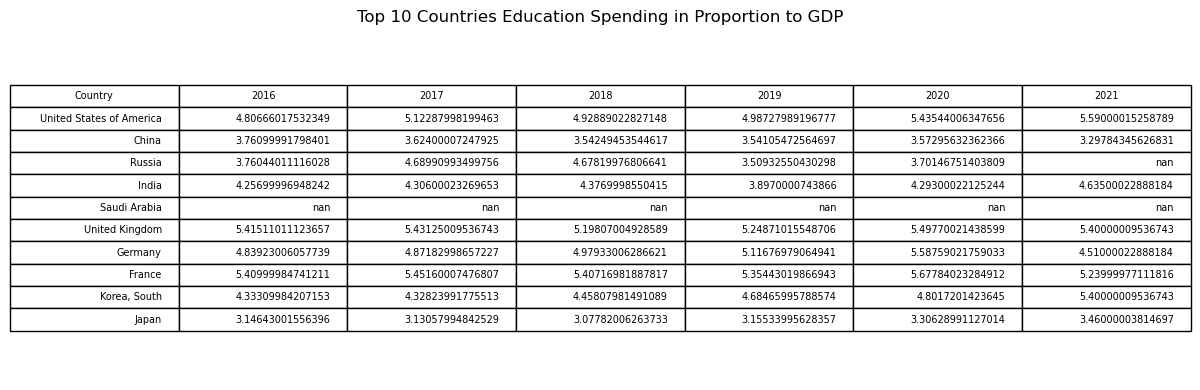

In [22]:
#save top educatiuon spending data as png table
#Saudi Arabia does not have data for our year range for this sheet, and Russia does not have data
#for 2021
save_df_png(
    top_education_percent_df,"Top 10 Countries Education Spending in Proportion to GDP", 
        "top_edu_spending_pct_table.png")

In [23]:
#Creates line graph showing education spending as percent of gdp
def edu_pct_line_graph():
    
    country_list = top_education_percent_df['Country'].tolist()
    education_graph_df = top_education_percent_df.dropna(how='all', subset=years)
    education_graph_indexed_country = education_graph_df.set_index('Country')
    edu_graph_indexed_country_transpose = education_graph_indexed_country.transpose()
    
    plt.figure(figsize=(12,8))
    plt.plot(edu_graph_indexed_country_transpose,label=education_graph_df['Country'].tolist())
    plt.title('Education Spending in Proportion to GDP')
    plt.xlabel('Year')
    plt.ylabel('percentage')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1.01), loc='upper left')
    plt.savefig('edu_spending_pct_gdp_line_graph.png')
    plt.show()

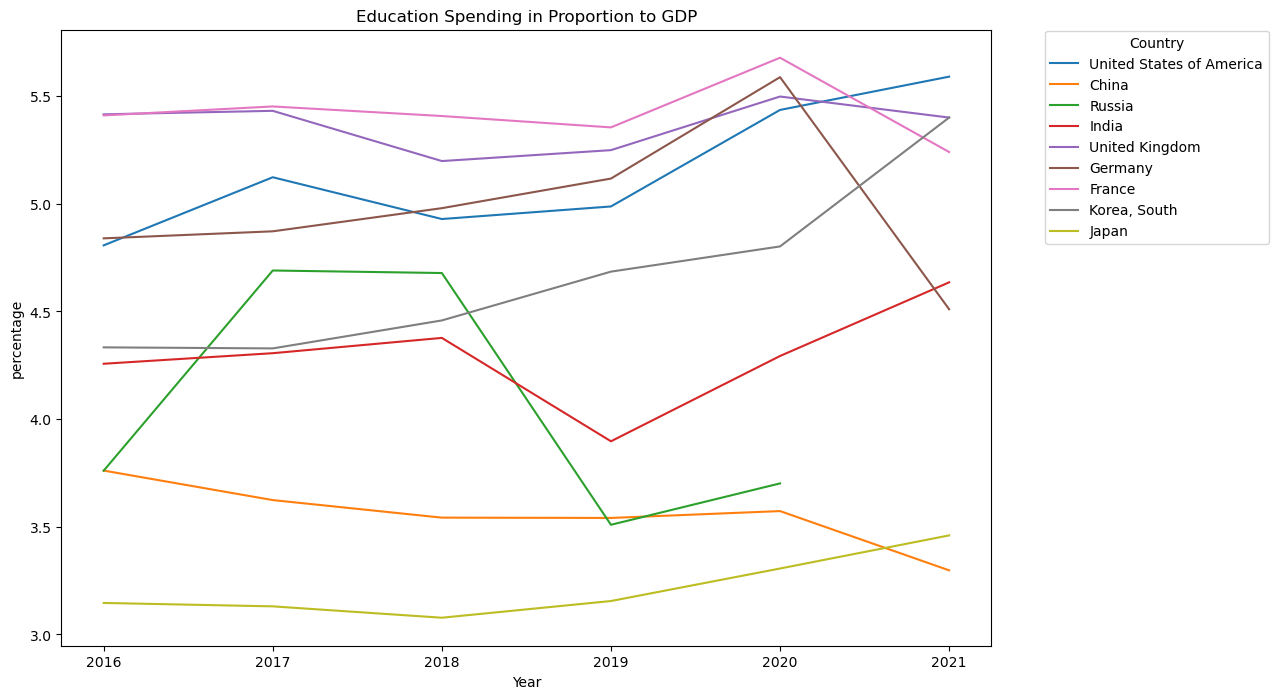

In [24]:
edu_pct_line_graph()

In [25]:
 #creates function to read and clean wb data files (edu, healthcare, etc)
def clean_wb_data(file):
    
    wb_years = []
    for year in years:
        wb_years.append(str(year))
    
    wb_data_df = pd.read_excel(file, 'Data', skiprows=3)
    wb_data_df = wb_data_df[['Country Name'] + wb_years].copy()
    wb_data_df = wb_data_df.rename(columns={'Country Name': 'Country'})
    wb_data_df[wb_years] = wb_data_df[wb_years].apply(pd.to_numeric,errors='coerce')
    
    wb_data_df['Country'] = wb_data_df['Country'].replace(country_name_changes)
    wb_data_df = wb_data_df.rename(columns=year_name_changes)
    
    return wb_data_df

In [26]:
 #creates function to filter data to same top military countries
def filter_top_countries(wb_data_df):
    
    top_10_data_df = pd.DataFrame()
    
    for country in country_list:
        country_row = wb_data_df.loc[wb_data_df['Country'] == country]
        top_10_data_df = pd.concat([top_10_data_df, country_row])
    
    return top_10_data_df

In [27]:
# clean WB healthcare spending data
health_percent_df = clean_wb_data(health_file)
health_percent_df.head()

,Country,2016,2017,2018,2019,2020,2021
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,6.097986,5.953892,5.809334,5.830223,5.881779,5.865553
2,Afghanistan,11.818590,12.620817,14.208419,14.831320,15.533614,21.827950
3,Africa Western and Central,3.796931,3.817355,3.430338,3.417184,3.840715,4.140713
4,Angola,2.713150,2.793838,2.588796,2.475180,3.220706,2.960106


In [28]:
#filters healthcare spend data to same top countries
top_health_percent_df = filter_top_countries(health_percent_df)
top_health_percent_df

,Country,2016,2017,2018,2019,2020,2021
251,United States of America,16.802158,16.767502,16.629644,16.665806,18.756220,17.362568
40,China,4.979556,5.065922,5.167905,5.350278,5.593597,5.383605
202,Russia,5.290000,5.360000,5.360000,5.650000,7.570000,7.390000
109,India,3.500000,2.940000,2.860000,2.950000,3.340000,3.280000
205,Saudi Arabia,6.241431,6.031260,5.340631,5.467427,6.646299,5.968369
81,United Kingdom,9.728997,9.595879,9.730798,9.957620,12.158634,12.364699
55,Germany,11.241889,11.336176,11.480515,11.715507,12.692553,12.934130
77,France,11.470600,11.354694,11.207990,11.088859,12.130961,12.307873
126,"Korea, South",6.870499,7.047423,7.491198,8.174795,8.349771,9.331455
119,Japan,10.660000,10.660000,10.740000,10.970000,11.000000,10.820000


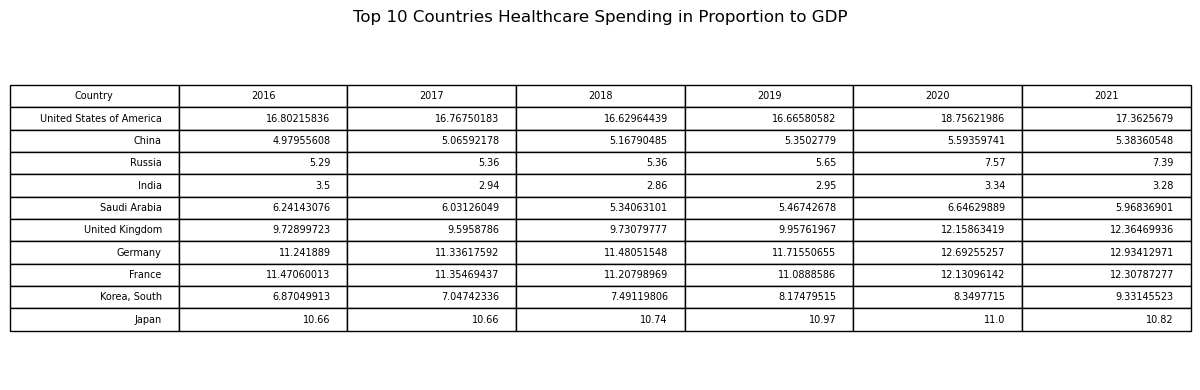

In [29]:
#save top healthcare spending data as png
save_df_png(top_health_percent_df,"Top 10 Countries Healthcare Spending in Proportion to GDP", 
    "top_healthcare_spending_pct_table.png"
)

In [30]:
#creates line graph showing spending as % of gdp
def spending_pct_gdp_line_graph(spending_df, graph_title, file_name):
    
    graph_df = spending_df.dropna(how='all', subset=years)
    
    graph_df_indexed_country = graph_df.set_index('Country')
    graph_df_indexed_country_transpose = graph_df_indexed_country.transpose()
    
    plt.figure(figsize=(12,7))
    plt.plot(graph_df_indexed_country_transpose,label=graph_df['Country'].tolist())
    plt.title(graph_title)
    
    plt.xlabel('Year')
    plt.ylabel('Percentage')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1.01), loc='upper left')
    plt.savefig(file_name)
    
    plt.show()

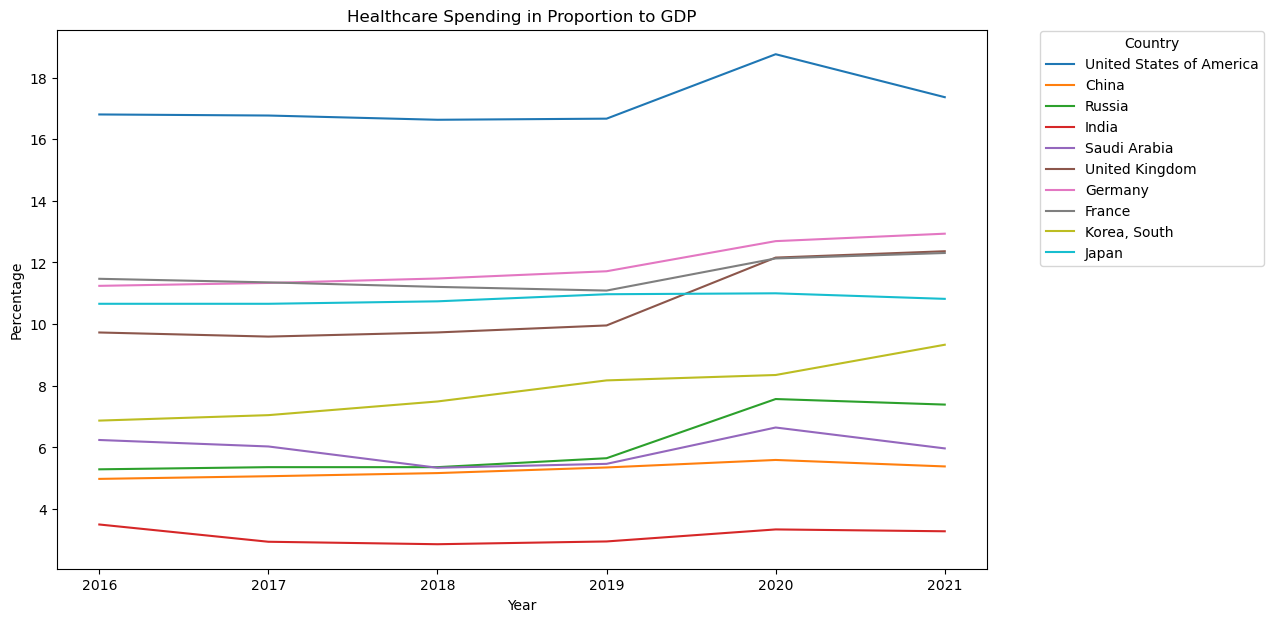

In [31]:
spending_pct_gdp_line_graph(top_health_percent_df,'Healthcare Spending in Proportion to GDP',
    'healthcare_spend_pct_gdp_linegraph.png')

In [32]:
#cleans World Bank total gdp data
gdp_df = clean_wb_data(gdp_file)
gdp_df.head()

,Country,2016,2017,2018,2019,2020,2021
0,Aruba,2.983637e+09,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09
1,Africa Eastern and Southern,8.318681e+11,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12
2,Afghanistan,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10
3,Africa Western and Central,7.000282e+11,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12
4,Angola,5.987825e+10,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10


In [33]:
# filters total gdp data to same top military spending countries
top_gdp_df = filter_top_countries(gdp_df)
top_gdp_df

,Country,2016,2017,2018,2019,2020,2021
251,United States of America,1.869511e+13,1.947734e+13,2.053306e+13,2.138098e+13,2.106047e+13,2.331508e+13
40,China,1.145602e+13,1.253756e+13,1.414777e+13,1.456017e+13,1.499641e+13,1.820170e+13
202,Russia,1.276786e+12,1.574199e+12,1.657329e+12,1.693115e+12,1.493076e+12,1.829187e+12
109,India,2.294797e+12,2.651474e+12,2.702930e+12,2.835606e+12,2.674852e+12,3.167271e+12
205,Saudi Arabia,6.892795e+11,7.412661e+11,8.865648e+11,8.888901e+11,7.679512e+11,9.826611e+11
81,United Kingdom,2.706808e+12,2.699118e+12,2.897028e+12,2.875710e+12,2.724001e+12,3.194559e+12
55,Germany,3.536788e+12,3.765352e+12,4.055433e+12,3.959895e+12,3.941399e+12,4.355252e+12
77,France,2.470408e+12,2.588868e+12,2.781576e+12,2.722794e+12,2.647926e+12,2.966434e+12
126,"Korea, South",1.579151e+12,1.710197e+12,1.824251e+12,1.751046e+12,1.744070e+12,1.942314e+12
119,Japan,5.003678e+12,4.930837e+12,5.040881e+12,5.117994e+12,5.054068e+12,5.039148e+12


In [34]:
 #calculates spending in current US millions from % of gdp data
def calculate_spending_dollars(percent_df, gdp_data_df):
    
    spend_dollar_df = percent_df.set_index('Country')
    gdp_data_df = gdp_data_df.set_index('Country')
    
    spend_dollar_df[years] = ((spend_dollar_df[years] / 100) * gdp_data_df[years] / 1000000) 
    spend_dollar_df = spend_dollar_df.reset_index()
    
    return spend_dollar_df

In [35]:
#Calculate education spending (current US millions)
top_education_dollars_df = calculate_spending_dollars(top_education_percent_df,
    top_gdp_df)

top_education_dollars_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,898610.447575,997800.575094,1.012052e+06,1.066329e+06,1.144729e+06,1.303313e+06
1,China,430861.056440,454361.149504,5.011838e+05,5.155835e+05,5.358153e+05,6.002635e+05
2,Russia,48012.786072,73828.532185,7.753315e+04,5.941692e+04,5.526572e+04,NaN
3,India,97689.502722,114172.487924,1.183072e+05,1.105036e+05,1.148314e+05,1.468030e+05
4,Saudi Arabia,NaN,NaN,NaN,NaN,NaN,NaN
5,United Kingdom,146576.612393,146595.870015,1.505895e+05,1.509377e+05,1.497574e+05,1.725062e+05
6,Germany,171153.303002,183441.529621,2.019334e+05,2.026187e+05,2.202292e+05,1.964219e+05
7,France,133649.048460,141134.747451,1.504046e+05,1.457901e+05,1.503450e+05,1.554411e+05
8,"Korea, South",68426.168642,74021.418696,8.132659e+04,8.203054e+04,8.374537e+04,1.048849e+05
9,Japan,157437.214755,154363.805968,1.551492e+05,1.614901e+05,1.671021e+05,1.743545e+05


In [36]:
#calculates healthcare spending in current USD (millions)
top_health_dollars_df = calculate_spending_dollars(top_health_percent_df,top_gdp_df)
top_health_dollars_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,3.141182e+06,3.265863e+06,3.414574e+06,3.563312e+06,3.950149e+06,4.048097e+06
1,China,5.704591e+05,6.351429e+05,7.311431e+05,7.790094e+05,8.388390e+05,9.799076e+05
2,Russia,6.754200e+04,8.437709e+04,8.883282e+04,9.566100e+04,1.130258e+05,1.351769e+05
3,India,8.031789e+04,7.795334e+04,7.730379e+04,8.365038e+04,8.934004e+04,1.038865e+05
4,Saudi Arabia,4.302090e+04,4.470769e+04,4.734815e+04,4.859942e+04,5.104033e+04,5.864884e+04
5,United Kingdom,2.633452e+05,2.590041e+05,2.819039e+05,2.863523e+05,3.312014e+05,3.949976e+05
6,Germany,3.976018e+05,4.268469e+05,4.655846e+05,4.639217e+05,5.002641e+05,5.633139e+05
7,France,2.833706e+05,2.939581e+05,3.117588e+05,3.019267e+05,3.212189e+05,3.651049e+05
8,"Korea, South",1.084955e+05,1.205248e+05,1.366583e+05,1.431444e+05,1.456259e+05,1.812461e+05
9,Japan,5.333920e+05,5.256273e+05,5.413906e+05,5.614439e+05,5.559475e+05,5.452358e+05


In [37]:
#sets most recent year from selected year range
compare_year = years[-1]

#creates df comparing military, education, and health spending in us millions

spending_comparison_df = top_10_df[['Country', compare_year]].copy()
spending_comparison_df = spending_comparison_df.rename(columns={compare_year: 'Military Spending'})

spending_comparison_df = spending_comparison_df.set_index('Country')
spending_comparison_df['Education Spending'] = (top_education_dollars_df.set_index('Country')[compare_year])

spending_comparison_df['Healthcare Spending'] = (top_health_dollars_df.set_index('Country')[compare_year])

spending_comparison_df = spending_comparison_df.reset_index()
spending_comparison_df

,Country,Military Spending,Education Spending,Healthcare Spending
0,United States of America,870751.188999,1.303313e+06,4.048097e+06
1,China,279605.778186,6.002635e+05,9.799076e+05
2,Russia,79081.150175,NaN,1.351769e+05
3,India,76596.864198,1.468030e+05,1.038865e+05
4,Saudi Arabia,64758.149307,NaN,5.864884e+04
5,United Kingdom,63008.189524,1.725062e+05,3.949976e+05
6,Germany,53715.839992,1.964219e+05,5.633139e+05
7,France,53011.698425,1.554411e+05,3.651049e+05
8,"Korea, South",47359.240475,1.048849e+05,1.812461e+05
9,Japan,43660.127990,1.743545e+05,5.452358e+05


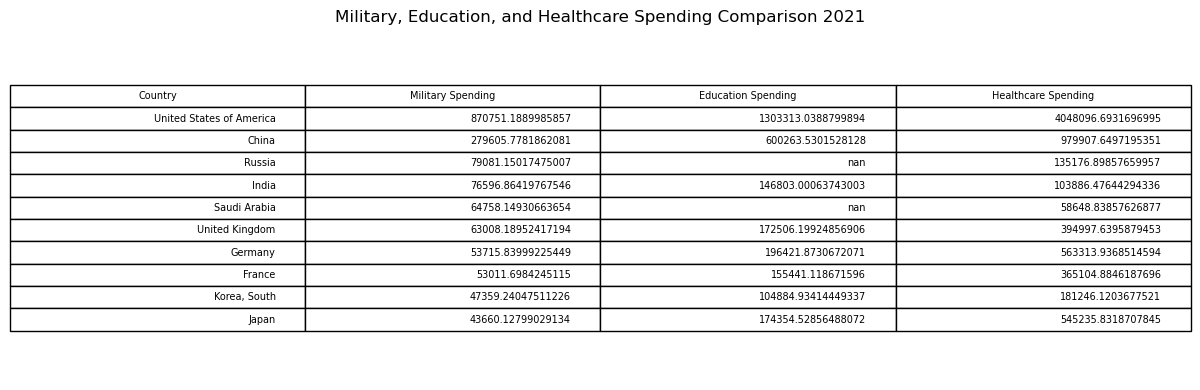

In [38]:
#saves absolute spending table as png
save_df_png(spending_comparison_df,"Military, Education, and Healthcare Spending Comparison 2021", 
    "military_education_healthcare_spending_comparison_2021_table.png"
)

In [39]:
#creates grouped bar chart comparing spending categories for 2021
def absolute_spend_compare_graph():
    
    graph_df = spending_comparison_df.set_index('Country')
    graph_df.plot(kind='bar',figsize=(14,8))
    plt.title('Military, Education, and Healthcare Spending Comparison 2021 (absolute)')
    plt.xlabel('country')
    plt.ylabel('Spending in Current USD (millions)')
    plt.xticks(rotation=45)
    plt.legend(title='Spending Category')
    plt.tight_layout()
    plt.savefig('mil_edu_health_spending_compare_graph.png')
    
    plt.show()

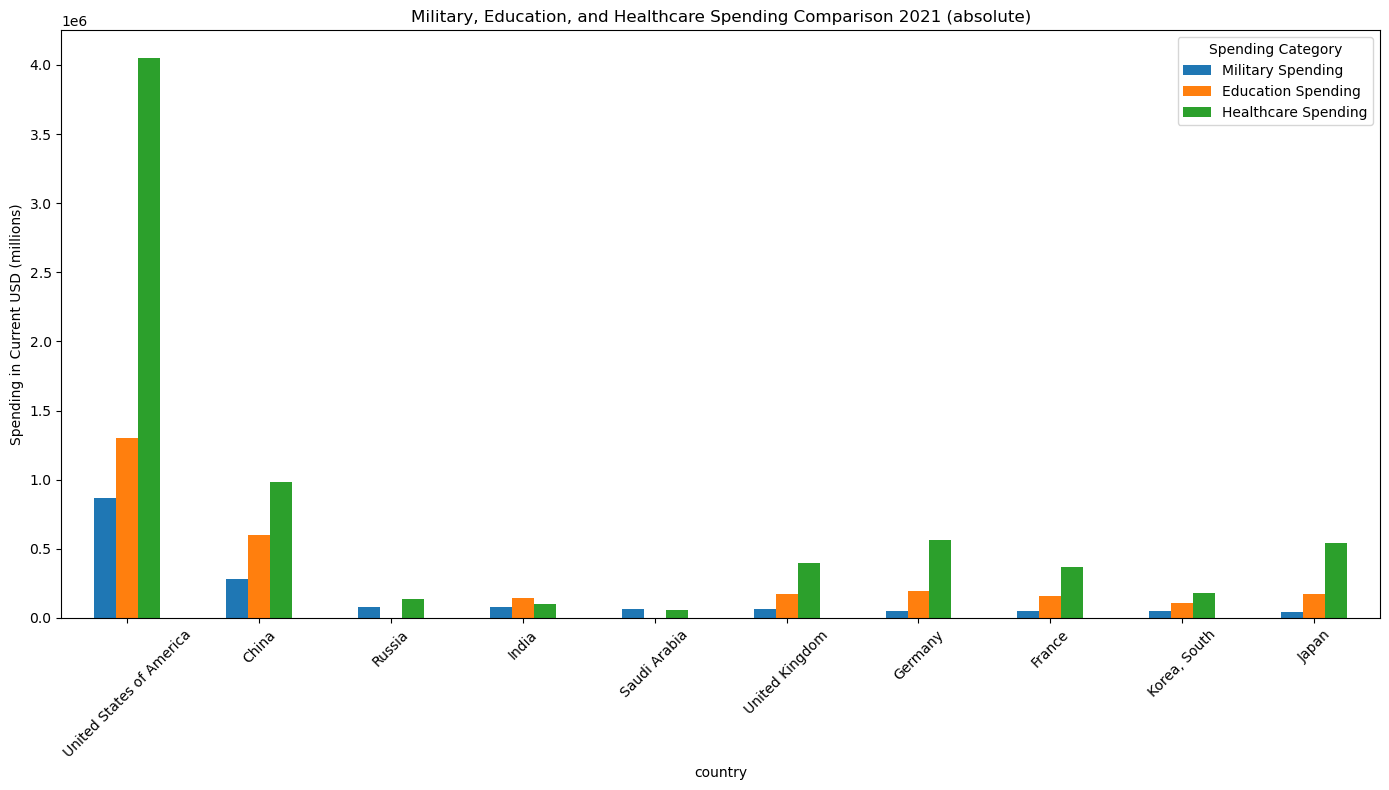

In [40]:
absolute_spend_compare_graph()

In [41]:
#creates  dataframe comparing military, education, and healthcare spending
# as % of gdp for most recent year

spend_pct_compare_df = top_gdp_percent_df[['Country', compare_year]].copy()
spend_pct_compare_df = spend_pct_compare_df.rename(columns={compare_year: 'Military spending % of GDP'})

spend_pct_compare_df = spend_pct_compare_df.set_index('Country')
spend_pct_compare_df['education spending % of GDP'] = (top_education_percent_df.set_index('Country')[compare_year])
spend_pct_compare_df['Healthcare Spending % of GDP'] = (top_health_percent_df.set_index('Country')[compare_year])
spend_pct_compare_df = spend_pct_compare_df.reset_index()

spend_pct_compare_df

,Country,Military spending % of GDP,education spending % of GDP,Healthcare Spending % of GDP
0,United States of America,3.417094,5.590000,17.362568
1,China,1.605260,3.297843,5.383605
2,Russia,3.611741,NaN,7.390000
3,India,2.480389,4.635000,3.280000
4,Saudi Arabia,7.229220,NaN,5.968369
5,United Kingdom,2.073222,5.400000,12.364699
6,Germany,1.321027,4.510000,12.934130
7,France,1.914406,5.240000,12.307873
8,"Korea, South",2.797473,5.400000,9.331455
9,Japan,1.017011,3.460000,10.820000


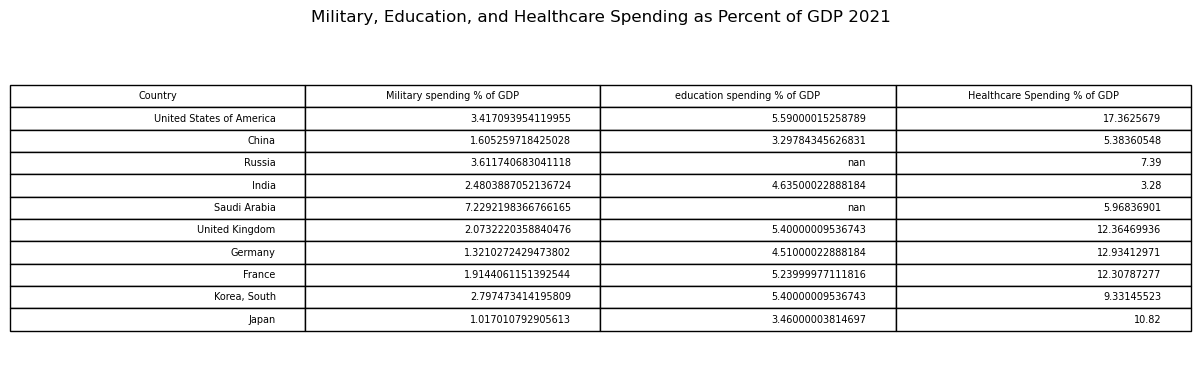

In [42]:
#saves percent spend comparison table as png
save_df_png(spend_pct_compare_df,"Military, Education, and Healthcare Spending as Percent of GDP 2021", 
    "military_edu_health_pct_comparison_table.png")

In [43]:
#creates grouped bar graph comparing spending percentgae for 2021
def pct_spend_comparison_graph():
    
    graph_df = spend_pct_compare_df.set_index('Country')
    
    graph_df.plot(kind='bar',figsize=(14,8))
    plt.title('Military, Education, and Healthcare Spending as a Percentage of GDP in 2021')
    plt.xlabel('Country')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.legend(title='Spending Category')
    plt.tight_layout()
    plt.savefig('military_edu_health_pct_compare_graph.png')
    
    plt.show()

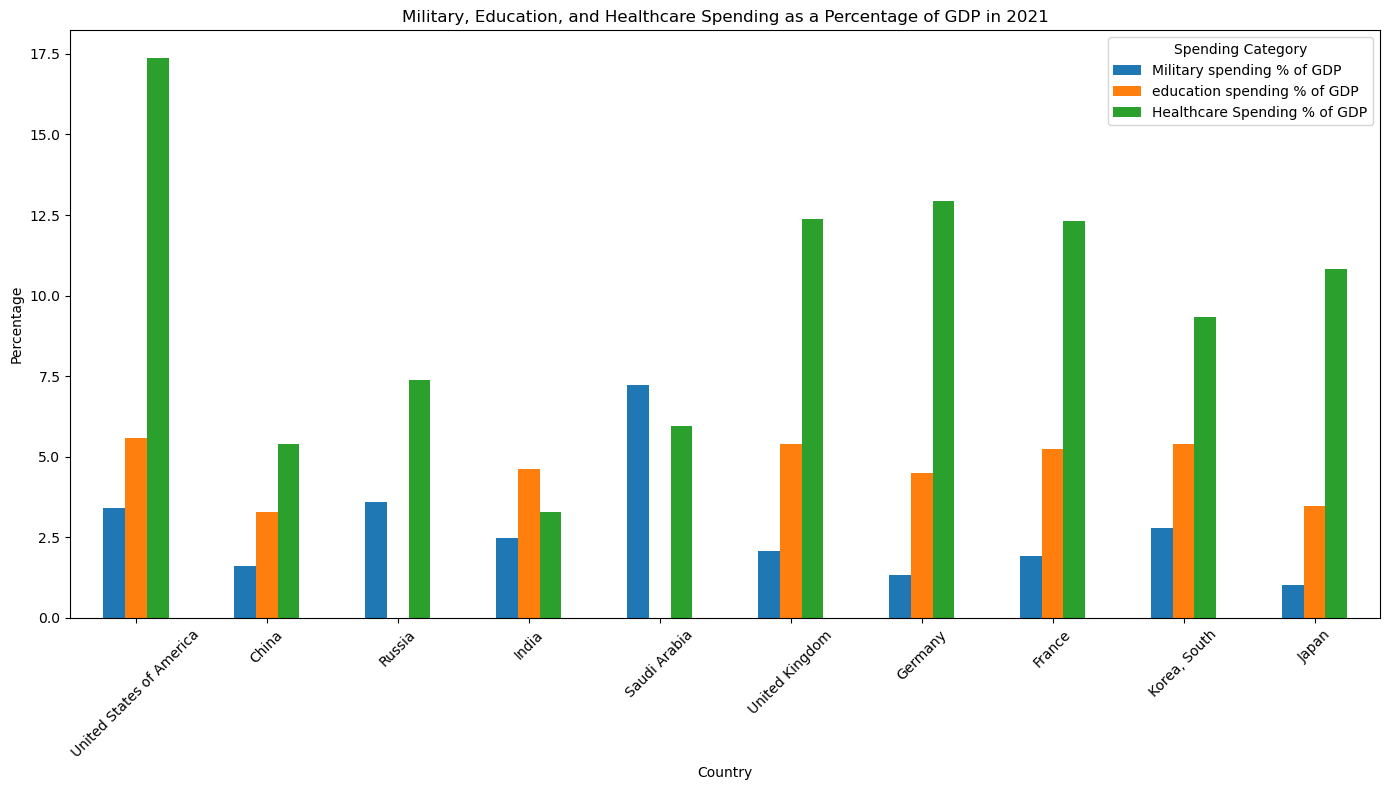

In [44]:
pct_spend_comparison_graph()

In [45]:
#clean WB population data 
population_df = clean_wb_data(pop_file)
population_df.head()

,Country,2016,2017,2018,2019,2020,2021
0,Aruba,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0
1,Africa Eastern and Southern,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0
2,Afghanistan,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0
3,Africa Western and Central,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0
4,Angola,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0


In [46]:
#Filters population data to same top military countries 
top_population_df = filter_top_countries(population_df)
top_population_df

,Country,2016,2017,2018,2019,2020,2021
251,United States of America,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08
40,China,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09
202,Russia,1.450155e+08,1.452933e+08,1.453981e+08,1.454533e+08,1.452451e+08,1.447468e+08
109,India,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09
205,Saudi Arabia,3.095420e+07,3.097736e+07,3.019628e+07,3.006380e+07,3.155251e+07,3.078438e+07
81,United Kingdom,6.560700e+07,6.596600e+07,6.628900e+07,6.663100e+07,6.674400e+07,6.698400e+07
55,Germany,8.234867e+07,8.265700e+07,8.290578e+07,8.309296e+07,8.316087e+07,8.319608e+07
77,France,6.672410e+07,6.691802e+07,6.715835e+07,6.738206e+07,6.760111e+07,6.784281e+07
126,"Korea, South",5.121780e+07,5.136191e+07,5.158506e+07,5.176482e+07,5.183624e+07,5.176954e+07
119,Japan,1.270760e+08,1.269720e+08,1.268110e+08,1.266330e+08,1.262610e+08,1.256816e+08


In [47]:
#creates function to calculate data values per person
def calculate_pp_data(data_df, population_data_df, mult):
    
    pp_df = data_df.set_index('Country')
    population_data_df = population_data_df.set_index('Country')
    
    pp_df[years] = ((pp_df[years] * mult) / population_data_df[years])
    pp_df = pp_df.reset_index()
    
    return pp_df

In [48]:
#Calculate education spending per person in US dollars  
top_education_pp_df = calculate_pp_data(top_education_dollars_df,top_population_df,1000000)
top_education_pp_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,2770.467687,3055.034520,3080.550204,3229.086715,3452.371348,3924.462453
1,China,310.465601,325.423484,357.284090,366.247783,379.714640,425.007456
2,Russia,331.087362,508.134597,533.247323,408.494825,380.499589,NaN
3,India,72.688655,83.971512,86.062959,79.554476,81.869339,103.806107
4,Saudi Arabia,NaN,NaN,NaN,NaN,NaN,NaN
5,United Kingdom,2234.161178,2222.294364,2271.712430,2265.277228,2243.758767,2575.334397
6,Germany,2078.397928,2219.310224,2435.697492,2438.458032,2648.231313,2360.951114
7,France,2003.010014,2109.069387,2239.551147,2163.633407,2224.002104,2291.195137
8,"Korea, South",1335.984065,1441.173376,1576.553153,1584.677316,1615.575809,2025.997066
9,Japan,1238.921706,1215.731074,1223.468350,1275.260833,1323.466000,1387.271791


In [49]:
#then calculates GDP per person in current usd
top_gdp_per_person_df = calculate_pp_data(top_gdp_df,top_population_df,1)
top_gdp_per_person_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,57638.101837,59635.098440,62499.874439,64746.450678,63515.949181,70205.050916
1,China,8254.868593,8979.676527,10085.663815,10342.900952,10627.463799,12887.435724
2,Russia,8804.484369,10834.634450,11398.558200,11640.266034,10279.695500,12637.151217
3,India,1707.508929,1950.104683,1966.254552,2041.428637,1907.042516,2239.613844
4,Saudi Arabia,22267.721705,23929.290714,29360.065897,29566.793383,24338.830730,31920.765366
5,United Kingdom,41257.908555,40916.811507,43702.997630,43158.741127,40812.679466,47691.376880
6,Germany,42948.938193,45553.934150,48916.168661,47656.199740,47394.873450,52349.245999
7,France,37024.215713,38687.162641,41418.176648,40408.284857,39169.860600,43725.099952
8,"Korea, South",30832.062807,33296.984544,35363.950823,33826.944330,33645.771955,37518.463531
9,Japan,39375.473162,38834.052934,39751.133098,40415.956765,40028.734173,40094.559980


In [50]:
#creates dataframe comparing education spending per person to GDP per person in
# absolute amounts and percentages for most recent year

education_pp_comparison_df = top_gdp_per_person_df[['Country', compare_year]].copy()
education_pp_comparison_df = education_pp_comparison_df.rename(columns={compare_year: 'GDP Per Person'})
education_pp_comparison_df = education_pp_comparison_df.set_index('Country')
education_pp_comparison_df['Education Spending Per Person'] = (top_education_pp_df.set_index('Country')[compare_year])

education_pp_comparison_df['Education Spending % of GDP Per Person'] = (
    (
        education_pp_comparison_df['Education Spending Per Person'] /
        education_pp_comparison_df['GDP Per Person']
    ) * 100
)

education_pp_comparison_df = education_pp_comparison_df.reset_index()
education_pp_comparison_df

,Country,GDP Per Person,Education Spending Per Person,Education Spending % of GDP Per Person
0,United States of America,70205.050916,3924.462453,5.590000
1,China,12887.435724,425.007456,3.297843
2,Russia,12637.151217,NaN,NaN
3,India,2239.613844,103.806107,4.635000
4,Saudi Arabia,31920.765366,NaN,NaN
5,United Kingdom,47691.376880,2575.334397,5.400000
6,Germany,52349.245999,2360.951114,4.510000
7,France,43725.099952,2291.195137,5.240000
8,"Korea, South",37518.463531,2025.997066,5.400000
9,Japan,40094.559980,1387.271791,3.460000


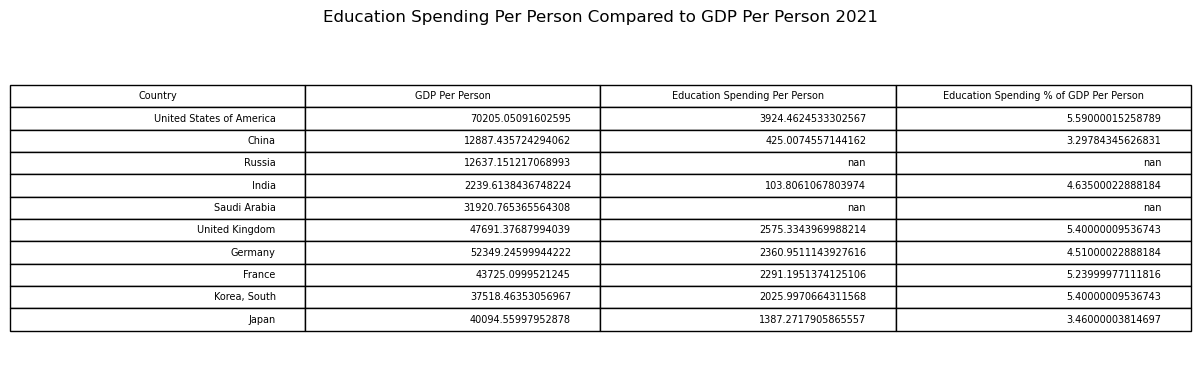

In [51]:
#saves education spending per person comparison table as png
save_df_png(education_pp_comparison_df,"Education Spending Per Person Compared to GDP Per Person 2021", 
    "edu_spending_pp_comparison_table.png")

In [52]:
# creates bar graph comparing spending per person to gdp per person
def pp_comparison_graph(comparison_df, graph_title, file_name):
    
    graph_df = comparison_df[['Country', 'GDP Per Person', 'Education Spending Per Person']].set_index('Country')
    
    graph_df.plot(kind='bar',figsize=(14,8))
    plt.title(graph_title)
    plt.xlabel('Country')
    plt.ylabel('Current USD Per Person')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(file_name)    
    plt.show()

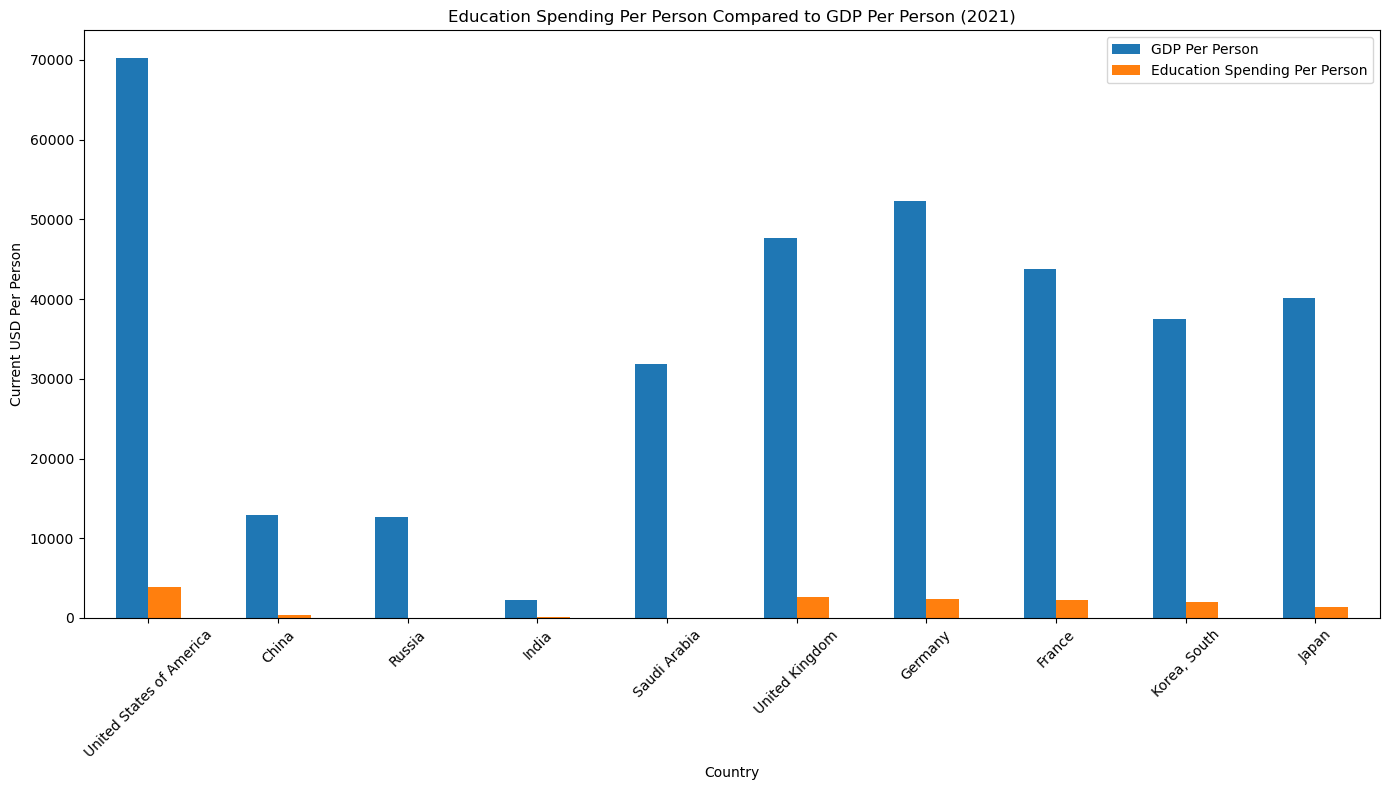

In [53]:
pp_comparison_graph(
    education_pp_comparison_df,'Education Spending Per Person Compared to GDP Per Person (2021)',
    'edu_spend_pp_comparison_graph.png')

In [54]:
#calculates healthcare spending per person
top_health_pp_df = calculate_pp_data(top_health_dollars_df,top_population_df,1000000)
top_health_pp_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,9684.445146,9999.316222,10393.506863,10790.517745,11913.191075,12189.399635
1,China,411.055811,454.903389,521.217509,553.373944,594.457540,693.808696
2,Russia,465.757223,580.736406,610.962720,657.675031,778.172949,933.885475
3,India,59.762813,57.333078,56.234880,60.222145,63.695220,73.459334
4,Saudi Arabia,1389.824432,1443.237856,1568.012784,1616.542779,1617.631437,1905.149068
5,United Kingdom,4013.980780,3926.327559,4252.650319,4297.583296,4962.264399,5896.895372
6,Germany,4828.271958,5164.074114,5615.828315,5583.165202,6015.619228,6770.919380
7,France,4246.899736,4392.809078,4642.144969,4480.817571,4751.680678,5381.629671
8,"Korea, South",2118.316607,2346.579467,2649.183598,2765.283404,2809.345078,3501.018627
9,Japan,4197.425439,4139.710043,4269.271695,4433.630457,4403.160759,4338.231390


In [55]:
#this creates data frame comparing healthcare spending per person to GDP per person
#in absolute amounts and percentages (most recent year)

health_pp_comparison_df = top_gdp_per_person_df[['Country', compare_year]].copy()
health_pp_comparison_df = health_pp_comparison_df.rename(columns={compare_year: 'GDP Per Person'})

health_pp_comparison_df = health_pp_comparison_df.set_index('Country')

health_pp_comparison_df['Healthcare Spending Per Person'] = (top_health_pp_df.set_index('Country')[compare_year])

health_pp_comparison_df['Healthcare Spending % of GDP Per Person'] = (
    (
        health_pp_comparison_df['Healthcare Spending Per Person'] /
        health_pp_comparison_df['GDP Per Person']
    ) * 100
)

health_pp_comparison_df = health_pp_comparison_df.reset_index()
health_pp_comparison_df

,Country,GDP Per Person,Healthcare Spending Per Person,Healthcare Spending % of GDP Per Person
0,United States of America,70205.050916,12189.399635,17.362568
1,China,12887.435724,693.808696,5.383605
2,Russia,12637.151217,933.885475,7.390000
3,India,2239.613844,73.459334,3.280000
4,Saudi Arabia,31920.765366,1905.149068,5.968369
5,United Kingdom,47691.376880,5896.895372,12.364699
6,Germany,52349.245999,6770.919380,12.934130
7,France,43725.099952,5381.629671,12.307873
8,"Korea, South",37518.463531,3501.018627,9.331455
9,Japan,40094.559980,4338.231390,10.820000


In [56]:
#create bar graph comparing spending per person to GDP per person
def pp_comparison_graph(comparison_df, spending_column, graph_title, file_name):
    
    graph_df = comparison_df[['Country', 'GDP Per Person', spending_column]].set_index('Country')
    graph_df.plot(kind='bar',figsize=(14,8))
    
    plt.title(graph_title)
    plt.xlabel('Country')
    plt.ylabel('Current USD Per Person')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(file_name)
    plt.show()

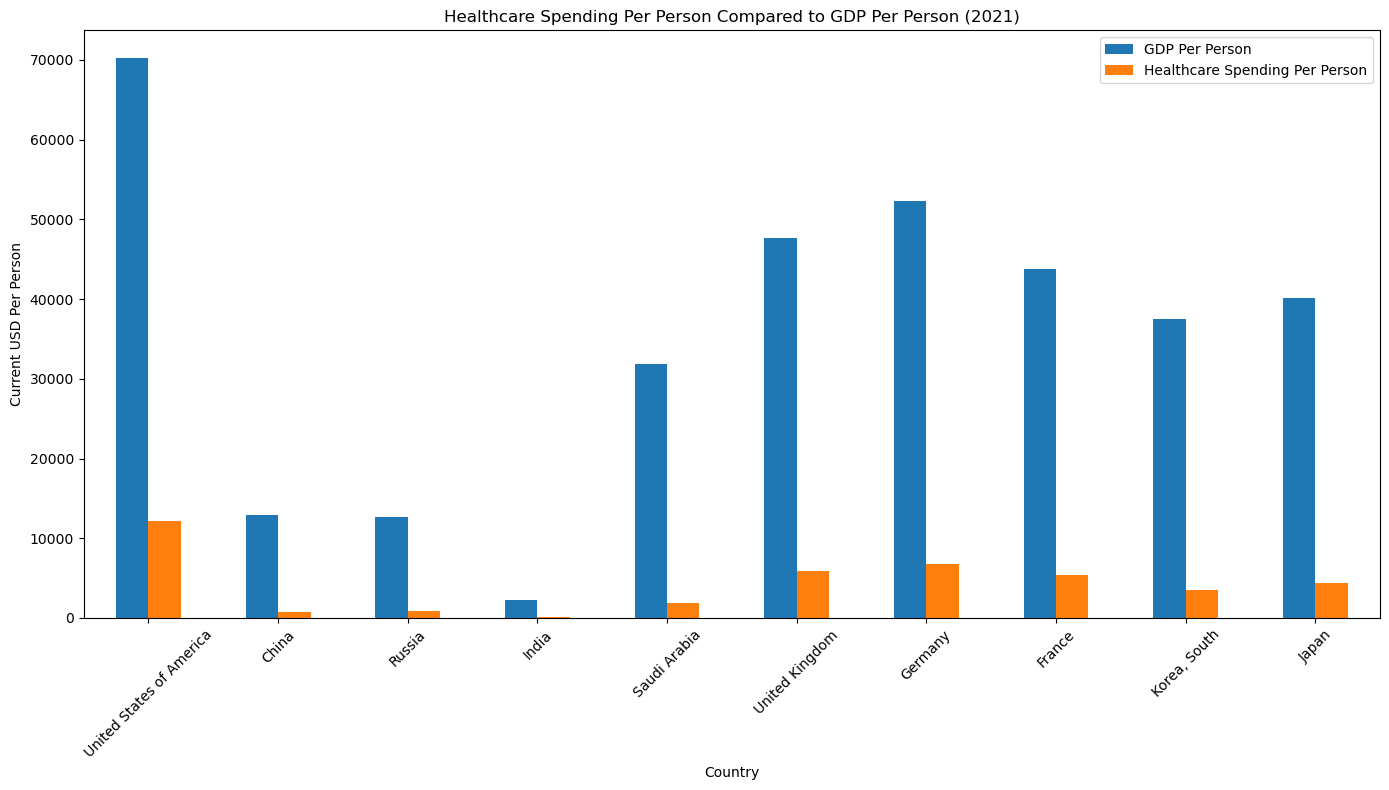

In [57]:
pp_comparison_graph(health_pp_comparison_df,'Healthcare Spending Per Person',
    'Healthcare Spending Per Person Compared to GDP Per Person (2021)',
    'healthcare_spending_pp_compare_graph.png')

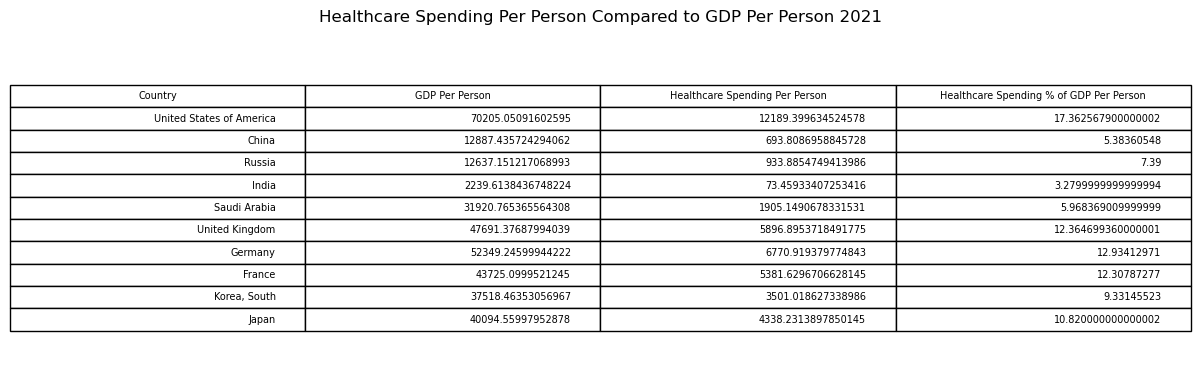

In [58]:
#saves healthcare spending per person table as png
save_df_png(health_pp_comparison_df,"Healthcare Spending Per Person Compared to GDP Per Person 2021", 
    "healthcare_spend_pp_comparison_table.png")

In [59]:
 #now calculates military spending per person in USD
top_military_per_person_df = calculate_pp_data(top_10_df,top_population_df,1000000)
top_military_per_person_df

,Country,2016,2017,2018,2019,2020,2021
0,United States of America,2405.446974,2364.223827,2421.140554,2545.572531,2654.536727,2621.956695
1,China,159.130449,167.897943,176.903505,184.864817,193.118174,197.970615
2,Russia,641.259046,518.632346,498.731575,520.888281,533.889848,546.341411
3,India,48.055624,50.846375,52.062524,55.161307,54.958290,54.162532
4,Saudi Arabia,2235.460431,2490.671757,2643.007960,2375.282854,2160.910840,2103.603938
5,United Kingdom,885.780653,882.569568,884.879430,916.907291,929.894691,940.645371
6,Germany,532.648433,545.882169,559.263216,612.095444,651.650878,645.653513
7,France,754.904185,762.620084,741.144566,750.888024,770.011262,781.390064
8,"Korea, South",728.026661,739.338607,773.474164,832.881523,875.496714,914.809005
9,Japan,316.010749,314.177379,330.411621,340.287379,338.364235,347.386813


In [60]:
#Creates data frame comparing military spending per person to gdp per person
# in absolute amounts and percentages

military_pp_comparison_df = top_gdp_per_person_df[['Country', compare_year]].copy()
military_pp_comparison_df = military_pp_comparison_df.rename(columns={compare_year: 'GDP Per Person'})

military_pp_comparison_df = military_pp_comparison_df.set_index('Country')

military_pp_comparison_df['Military Spending Per Person'] = (top_military_per_person_df.set_index('Country')[compare_year])
military_pp_comparison_df['Military Spending % of GDP Per Person'] = (
    (
        military_pp_comparison_df['Military Spending Per Person'] /
        military_pp_comparison_df['GDP Per Person']
    ) * 100
)

military_pp_comparison_df = military_pp_comparison_df.reset_index()
military_pp_comparison_df

,Country,GDP Per Person,Military Spending Per Person,Military Spending % of GDP Per Person
0,United States of America,70205.050916,2621.956695,3.734712
1,China,12887.435724,197.970615,1.536152
2,Russia,12637.151217,546.341411,4.323296
3,India,2239.613844,54.162532,2.418387
4,Saudi Arabia,31920.765366,2103.603938,6.590080
5,United Kingdom,47691.376880,940.645371,1.972359
6,Germany,52349.245999,645.653513,1.233358
7,France,43725.099952,781.390064,1.787052
8,"Korea, South",37518.463531,914.809005,2.438290
9,Japan,40094.559980,347.386813,0.866419


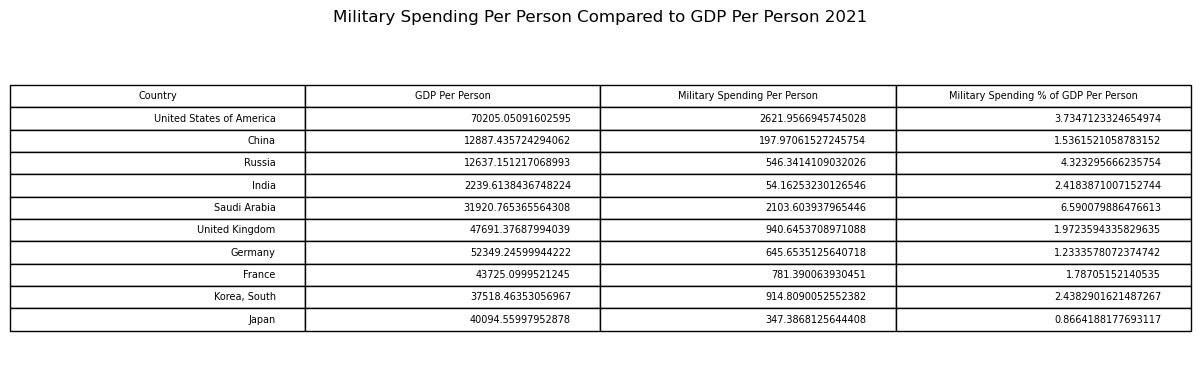

In [61]:
#Save military spending per person comparison table as png
save_df_png(military_pp_comparison_df, "Military Spending Per Person Compared to GDP Per Person 2021", 
    "military_spending_pp_comparison_table.png")

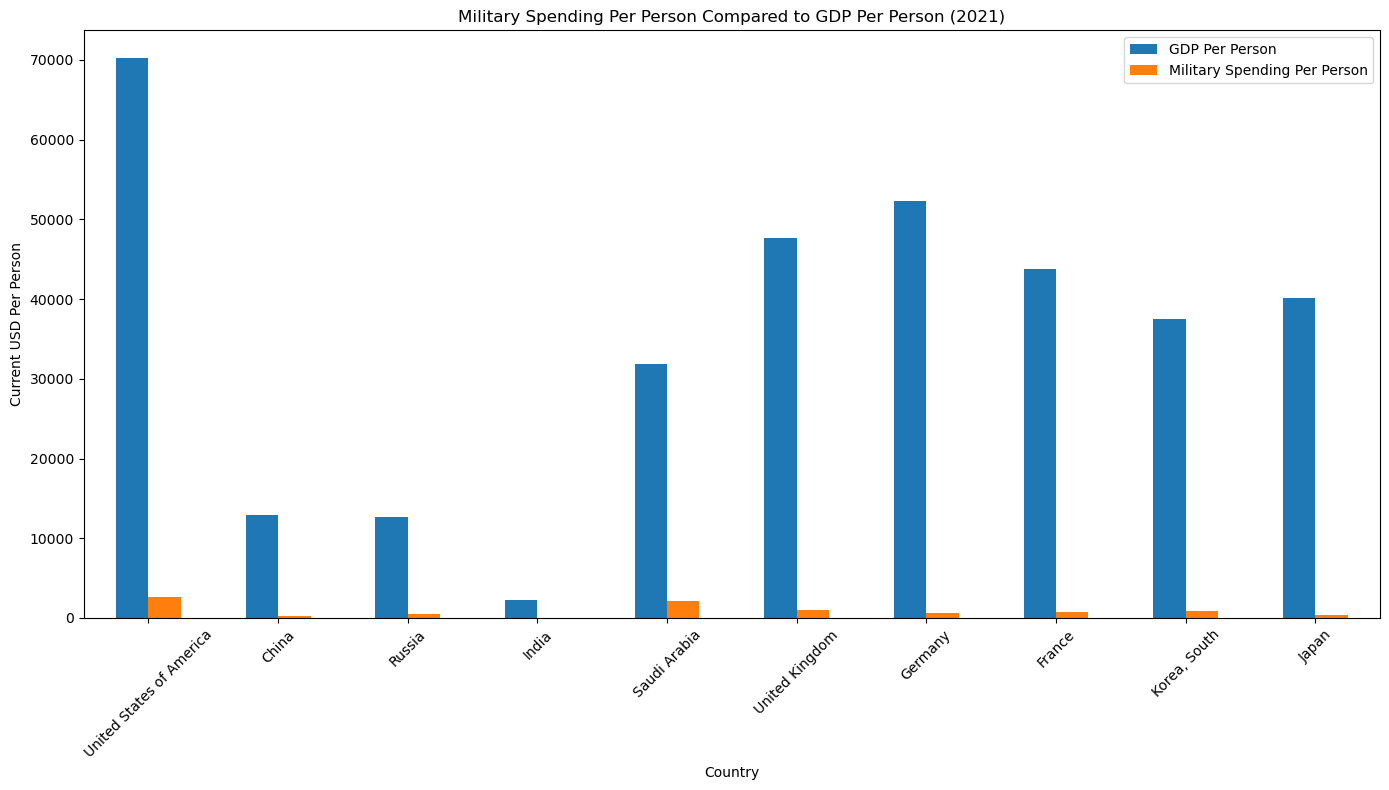

In [62]:
pp_comparison_graph(military_pp_comparison_df,'Military Spending Per Person',
    'Military Spending Per Person Compared to GDP Per Person (2021)',
    'military_spending_per_person_comparison_2021_graph.png')

In [63]:
#create data frame showing absolute and percent spend growth
def calculate_spend_growth(spending_df):
    
    growth_df = spending_df[['Country', years[0], years[-1]]].copy()
    growth_df = growth_df.dropna()
    
    growth_df['Absolute Growth in Current USD Millions'] = (growth_df[years[-1]] - growth_df[years[0]])
    growth_df['Percentage Growth'] = (
        (
            growth_df['Absolute Growth in Current USD Millions'] /
            growth_df[years[0]]
        ) * 100
    )
    
    return growth_df

In [64]:
# calculates education spending growth from 2016 to 2021
education_growth_df = calculate_spend_growth(top_education_dollars_df)
education_growth_df

,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
0,United States of America,898610.447575,1.303313e+06,404702.591305,45.036489
1,China,430861.056440,6.002635e+05,169402.473713,39.317193
3,India,97689.502722,1.468030e+05,49113.497915,50.275103
5,United Kingdom,146576.612393,1.725062e+05,25929.586855,17.690126
6,Germany,171153.303002,1.964219e+05,25268.570065,14.763706
7,France,133649.048460,1.554411e+05,21792.070211,16.305444
8,"Korea, South",68426.168642,1.048849e+05,36458.765502,53.281904
9,Japan,157437.214755,1.743545e+05,16917.313810,10.745435


In [65]:
#sorts education spend growth by absolute dollar increase
education_abs_growth_df = education_growth_df.sort_values(by='Absolute Growth in Current USD Millions',ascending=False)
education_abs_growth_df

,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
0,United States of America,898610.447575,1.303313e+06,404702.591305,45.036489
1,China,430861.056440,6.002635e+05,169402.473713,39.317193
3,India,97689.502722,1.468030e+05,49113.497915,50.275103
8,"Korea, South",68426.168642,1.048849e+05,36458.765502,53.281904
5,United Kingdom,146576.612393,1.725062e+05,25929.586855,17.690126
6,Germany,171153.303002,1.964219e+05,25268.570065,14.763706
7,France,133649.048460,1.554411e+05,21792.070211,16.305444
9,Japan,157437.214755,1.743545e+05,16917.313810,10.745435


In [66]:
 #sorts education spending growth by percent increase
education_pct_growth_df = education_growth_df.sort_values(by='Percentage Growth',ascending=False)

education_pct_growth_df

,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
8,"Korea, South",68426.168642,1.048849e+05,36458.765502,53.281904
3,India,97689.502722,1.468030e+05,49113.497915,50.275103
0,United States of America,898610.447575,1.303313e+06,404702.591305,45.036489
1,China,430861.056440,6.002635e+05,169402.473713,39.317193
5,United Kingdom,146576.612393,1.725062e+05,25929.586855,17.690126
7,France,133649.048460,1.554411e+05,21792.070211,16.305444
6,Germany,171153.303002,1.964219e+05,25268.570065,14.763706
9,Japan,157437.214755,1.743545e+05,16917.313810,10.745435


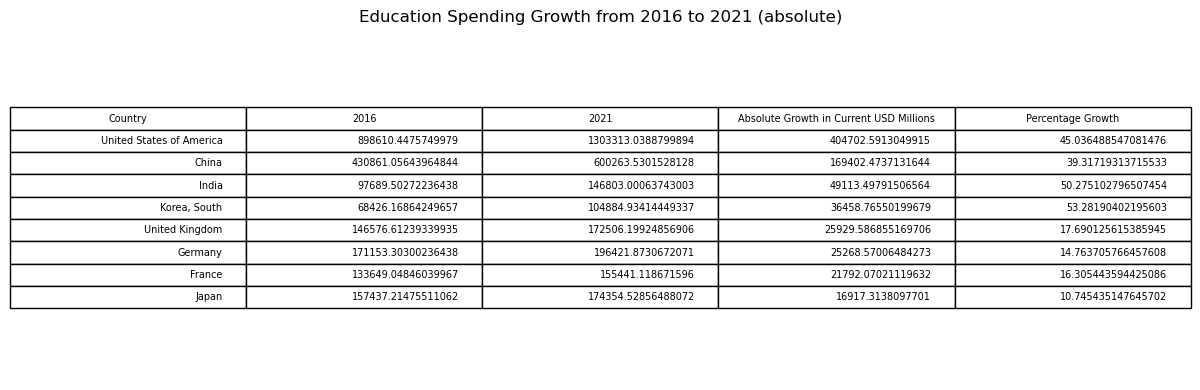

In [67]:
#saves education abs growth table as png
save_df_png(education_abs_growth_df,"Education Spending Growth from 2016 to 2021 (absolute)", 
    "education_absolute_growth_2016_2021_table.png")


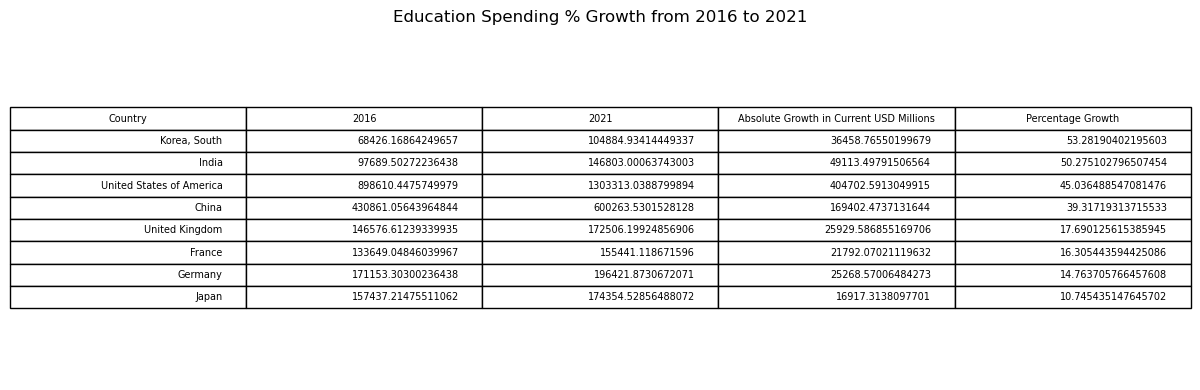

In [68]:
#save education percent growth table as png
save_df_png(education_pct_growth_df,"Education Spending % Growth from 2016 to 2021", 
    "education_percentage_growth_2016_2021_table.png")

In [69]:
#creates bar graph showing spending growth
def spending_growth_graph(growth_df, growth_column, graph_title, y_label, file_name):
    
    graph_df = growth_df[['Country', growth_column]].set_index('Country')
    graph_df.plot(kind='bar',figsize=(14,8))
    
    plt.title(graph_title)
    plt.xlabel('Country')
    plt.ylabel(y_label)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig(file_name)
    plt.show()

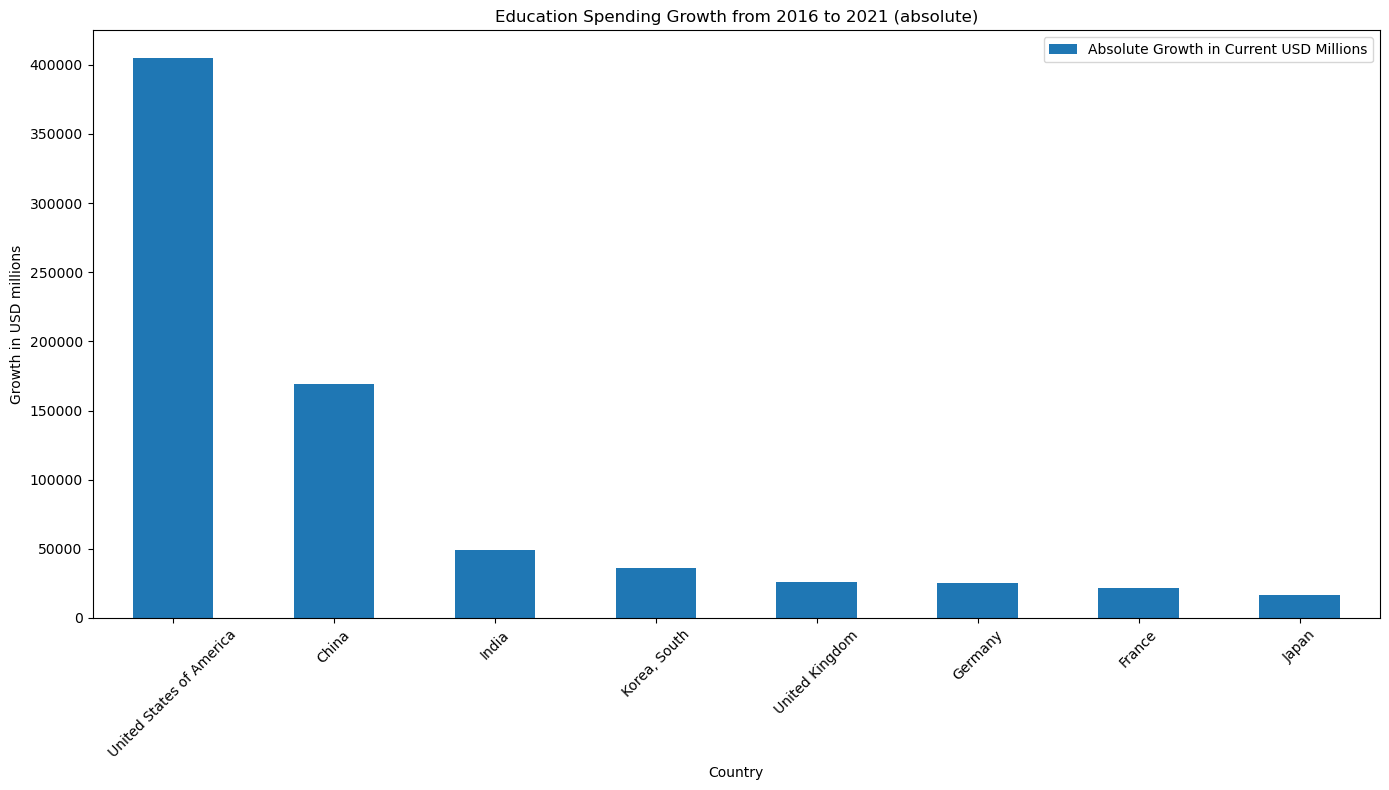

In [70]:
spending_growth_graph(education_abs_growth_df,'Absolute Growth in Current USD Millions',
    'Education Spending Growth from 2016 to 2021 (absolute)',
    'Growth in USD millions',
    'education_abs_growth_graph.png')

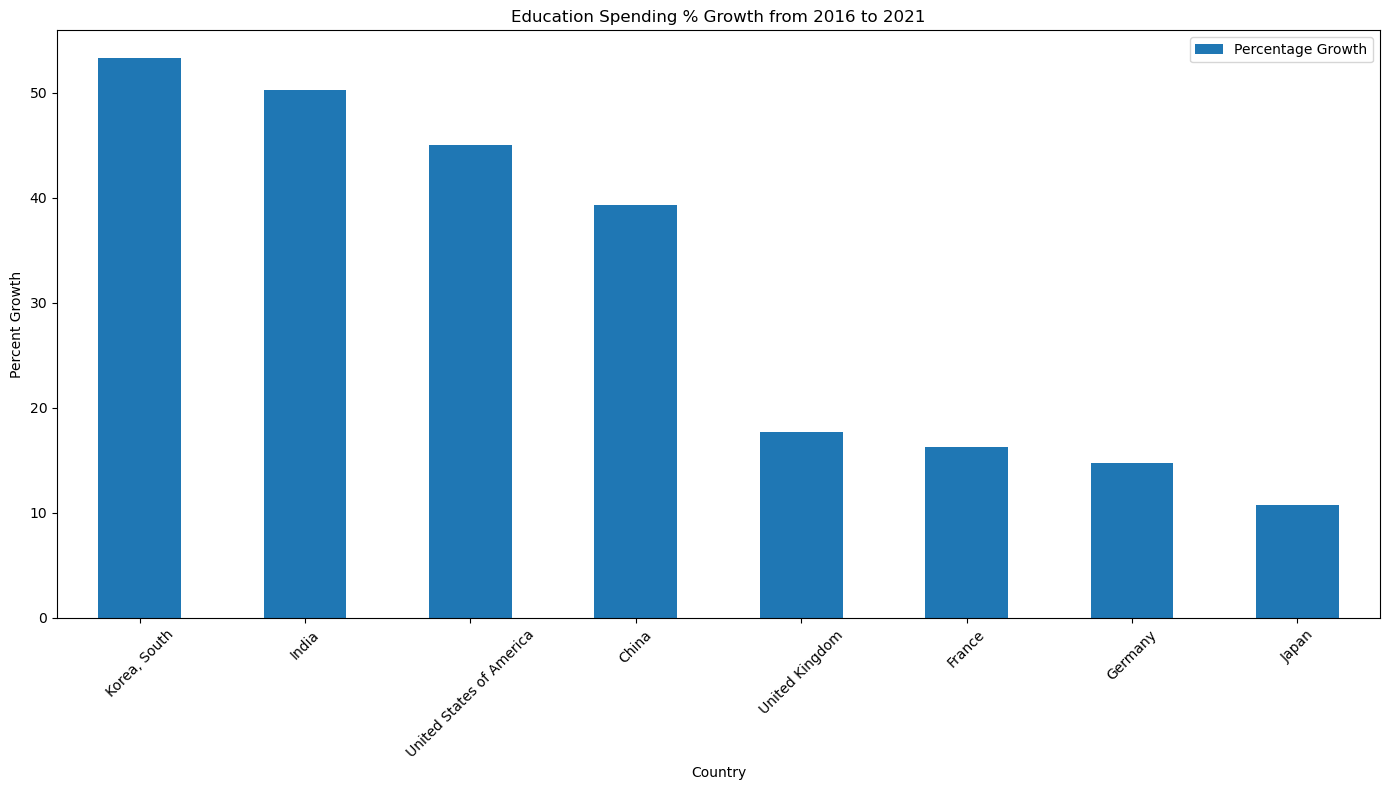

In [71]:
spending_growth_graph(
    education_pct_growth_df,'Percentage Growth','Education Spending % Growth from 2016 to 2021',
    'Percent Growth','education_pct_growth_graph.png')

In [72]:
 #calculates healthcare spending growth from 2016 to 2021
health_growth_df = calculate_spend_growth(top_health_dollars_df)
health_growth_df

,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
0,United States of America,3.141182e+06,4.048097e+06,906914.563919,28.871760
1,China,5.704591e+05,9.799076e+05,409448.505871,71.775255
2,Russia,6.754200e+04,1.351769e+05,67634.900615,100.137548
3,India,8.031789e+04,1.038865e+05,23568.585445,29.344129
4,Saudi Arabia,4.302090e+04,5.864884e+04,15627.937921,36.326385
5,United Kingdom,2.633452e+05,3.949976e+05,131652.402526,49.992323
6,Germany,3.976018e+05,5.633139e+05,165712.167510,41.677925
7,France,2.833706e+05,3.651049e+05,81734.304973,28.843610
8,"Korea, South",1.084955e+05,1.812461e+05,72750.597702,67.054009
9,Japan,5.333920e+05,5.452358e+05,11843.796775,2.220467


In [73]:
#sorts healthcare spend growth by dollar increase (absolute)

health_abs_growth_df = health_growth_df.sort_values(by='Absolute Growth in Current USD Millions',ascending=False)
health_abs_growth_df

,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
0,United States of America,3.141182e+06,4.048097e+06,906914.563919,28.871760
1,China,5.704591e+05,9.799076e+05,409448.505871,71.775255
6,Germany,3.976018e+05,5.633139e+05,165712.167510,41.677925
5,United Kingdom,2.633452e+05,3.949976e+05,131652.402526,49.992323
7,France,2.833706e+05,3.651049e+05,81734.304973,28.843610
8,"Korea, South",1.084955e+05,1.812461e+05,72750.597702,67.054009
2,Russia,6.754200e+04,1.351769e+05,67634.900615,100.137548
3,India,8.031789e+04,1.038865e+05,23568.585445,29.344129
4,Saudi Arabia,4.302090e+04,5.864884e+04,15627.937921,36.326385
9,Japan,5.333920e+05,5.452358e+05,11843.796775,2.220467


In [74]:
#sorts healthcare spending growth by percent increase
health_pct_growth_df = health_growth_df.sort_values(by='Percentage Growth',ascending=False)
health_pct_growth_df


,Country,2016,2021,Absolute Growth in Current USD Millions,Percentage Growth
2,Russia,6.754200e+04,1.351769e+05,67634.900615,100.137548
1,China,5.704591e+05,9.799076e+05,409448.505871,71.775255
8,"Korea, South",1.084955e+05,1.812461e+05,72750.597702,67.054009
5,United Kingdom,2.633452e+05,3.949976e+05,131652.402526,49.992323
6,Germany,3.976018e+05,5.633139e+05,165712.167510,41.677925
4,Saudi Arabia,4.302090e+04,5.864884e+04,15627.937921,36.326385
3,India,8.031789e+04,1.038865e+05,23568.585445,29.344129
0,United States of America,3.141182e+06,4.048097e+06,906914.563919,28.871760
7,France,2.833706e+05,3.651049e+05,81734.304973,28.843610
9,Japan,5.333920e+05,5.452358e+05,11843.796775,2.220467


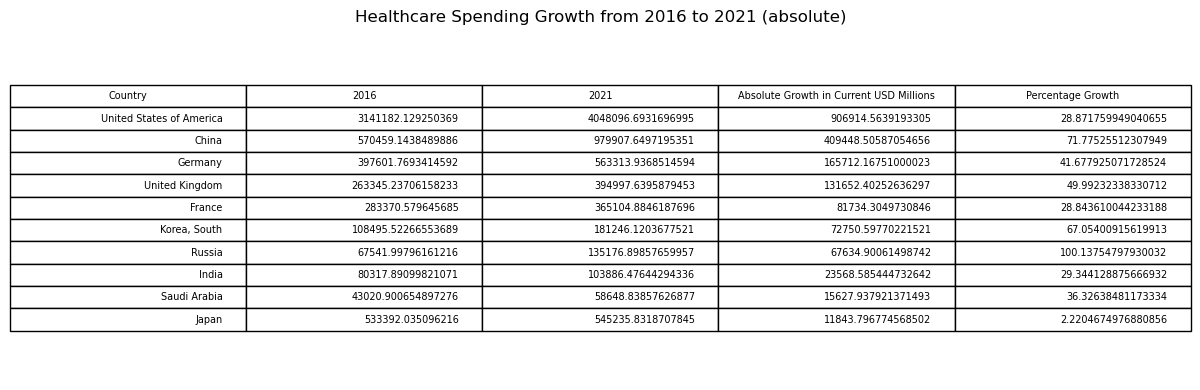

In [75]:
#saves healthcare absolute growth table as png
save_df_png(health_abs_growth_df,"Healthcare Spending Growth from 2016 to 2021 (absolute)", 
    "healthcare_abs_growth_table.png")

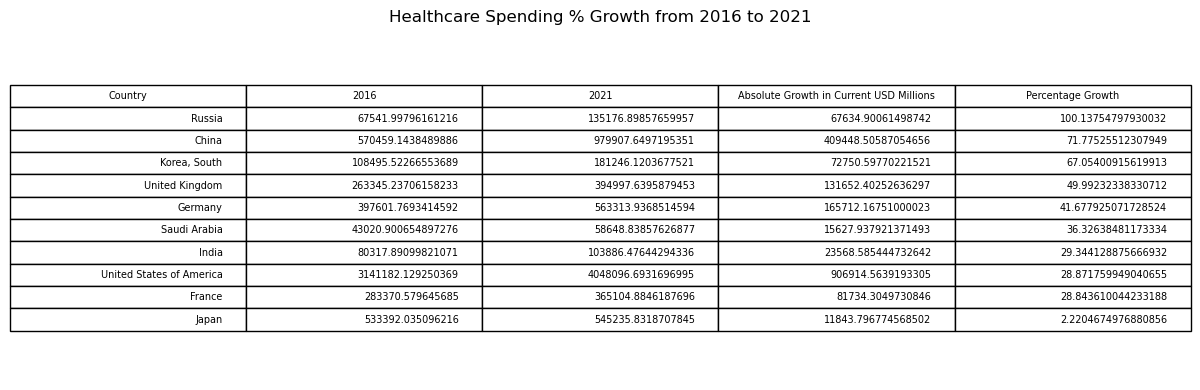

In [76]:
#save healthcare pct growth table as png
save_df_png(health_pct_growth_df,"Healthcare Spending % Growth from 2016 to 2021", 
    "healthcare_pct_growth_table.png")

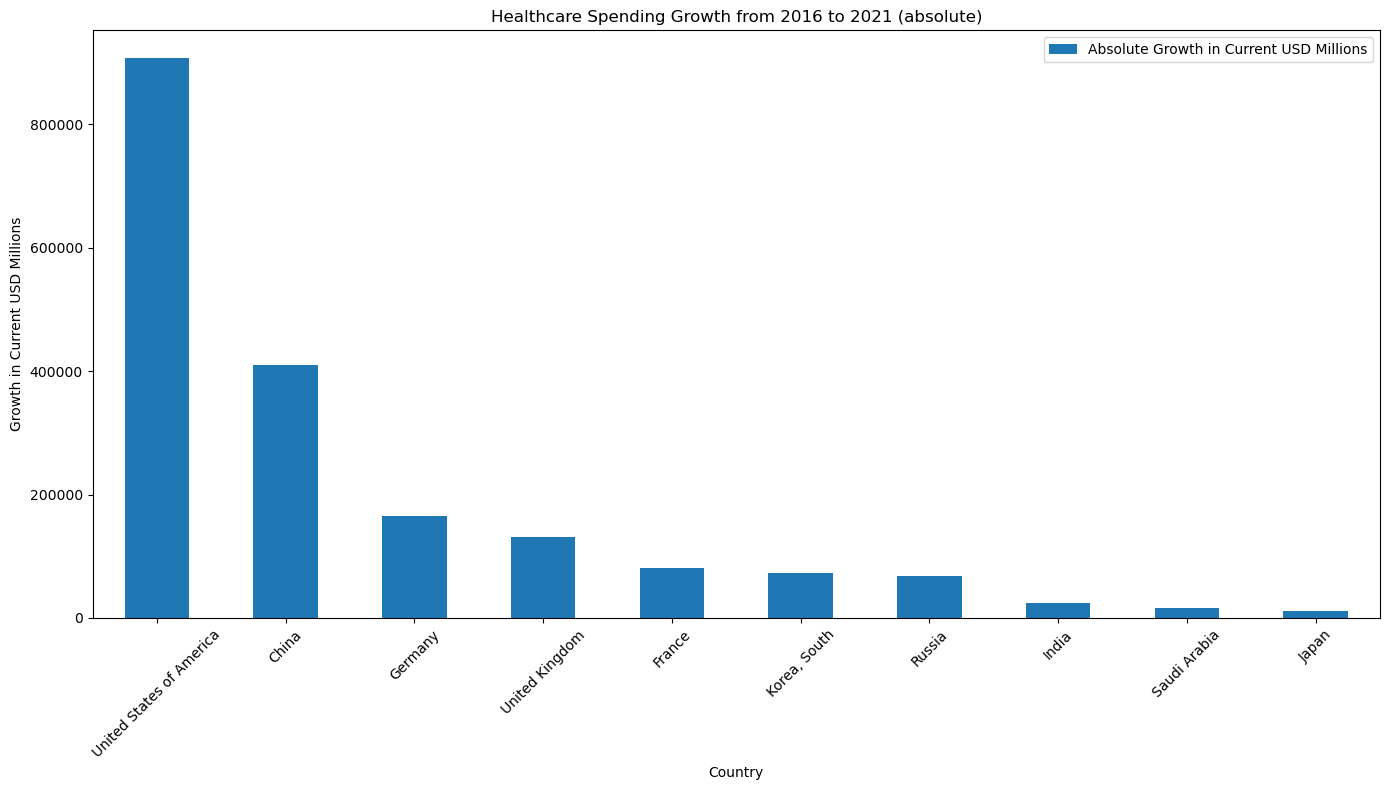

In [77]:
spending_growth_graph(health_abs_growth_df,'Absolute Growth in Current USD Millions','Healthcare Spending Growth from 2016 to 2021 (absolute)',
    'Growth in Current USD Millions','healthcare_abs_growth_graph.png'
)

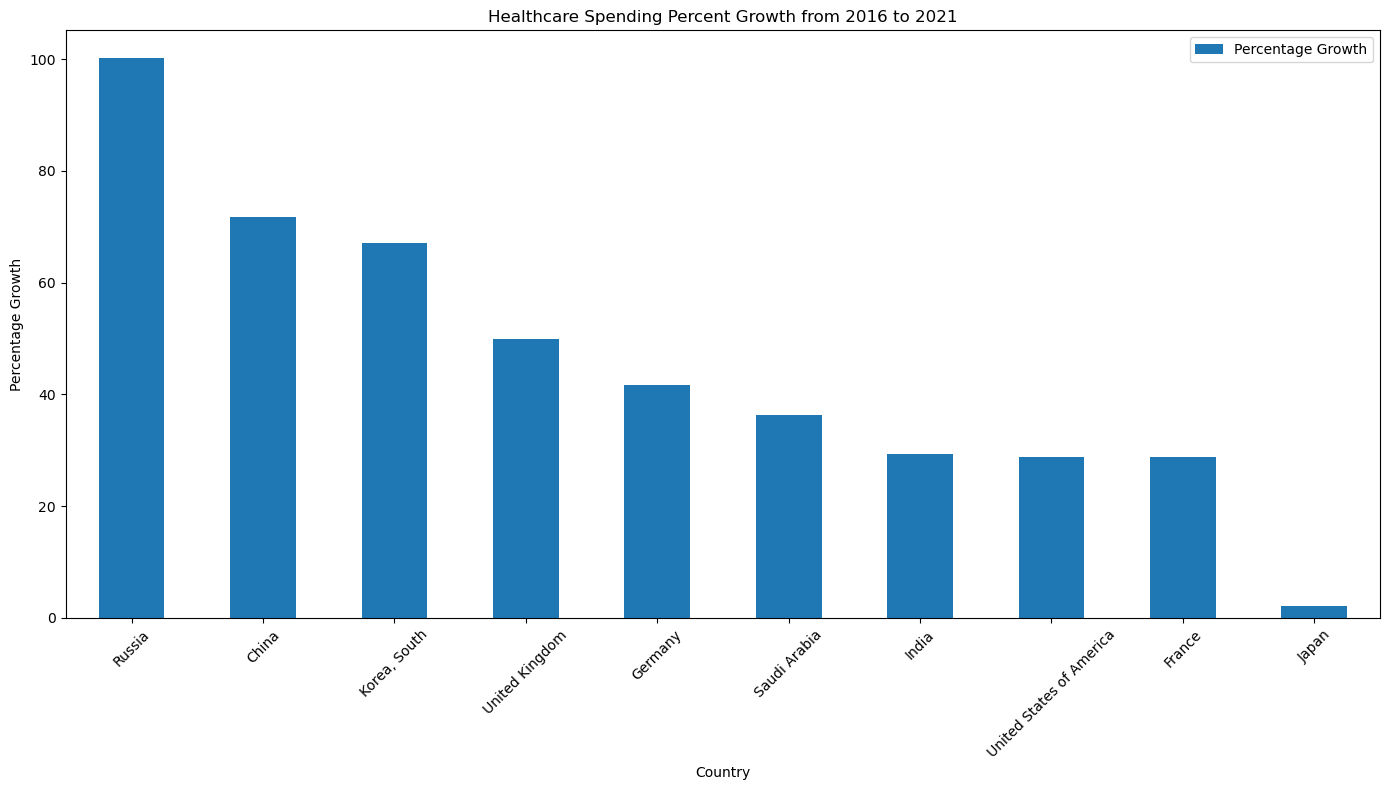

In [78]:
spending_growth_graph(health_pct_growth_df,
    'Percentage Growth','Healthcare Spending Percent Growth from 2016 to 2021','Percentage Growth',
    'healthcare_percentage_growth_2016_2021_graph.png'
)